In [ ]:
import h5py
import pickle
import numpy as np
import matplotlib.pyplot as plt
from cell_data import calculate_purity,cluster_matrix_hierarchical
import behave_ana
from scipy.stats import zscore,entropy
import matplotlib.gridspec as gridspec
from scipy.stats import sem  # 标准误差
from scipy.cluster.hierarchy import dendrogram,fcluster
from scipy.ndimage import uniform_filter1d
from cell_data import GLMDecoder,match_segments
from pathlib import Path
try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

In [ ]:
# 匹配 HDF5 文件
pkl_dir = '/home/zyyk78/HDD/zyyk78/Stage4/C03'
h5_root_dir = '/home/zyyk78/HDD/zyyk78/Stage4/Miniscope/C03'
mode = 'C'

pkl_dict = {}
result_pairs = []
for pkl_file in Path(pkl_dir).glob("*.pkl"):
    # 提取日期：这里假设日期是前8位数字
    date_key = pkl_file.name[:8] 
    pkl_dict[date_key] = str(pkl_file)
    
for h5_file in Path(h5_root_dir).rglob("*.hdf5"):
    folder_date = h5_file.relative_to(h5_root_dir).parts[0].replace("_", "")
    
    if folder_date in pkl_dict:
        result_pairs.append((pkl_dict[folder_date], str(h5_file)))
        
for idx, (pkl_path, h5_path) in enumerate(result_pairs):
    print(f'ID:{idx} PKL: {pkl_path} HDF5: {h5_path}')

In [ ]:
keep_list=['MinS','SlnL','SlnR','ROmL','ROmR','LickL','LickR']
long_event=['Blackhole','MinS']
results = []
for ID in range(len(result_pairs)):
    smooth_w = 0.5
    with h5py.File(result_pairs[ID][1], 'r') as hdf_file:
        fr = hdf_file['params']['data']['fr'][()]
        C = np.array(hdf_file['estimates']['C'])
        C_z = zscore(C, axis=1)
        S = np.array(hdf_file['estimates']['S'])
        S_sm = uniform_filter1d(S, size = int(smooth_w*fr), axis=1)
        S_z = zscore(S_sm, axis=1)
    with open(result_pairs[ID][0],"rb") as pkl_f:
            Event=pickle.load(pkl_f)
    if mode == 'S':
        signal = S_z
        print('钙信号模式')
    elif mode == 'C':
        signal = C_z
        print('反卷积模式')
    ignore_list=[i for i in list(Event.keys()) if i not in keep_list]
    eve_list=behave_ana.sort_events(Event,ignore_list=ignore_list,long_event=long_event)
    try:
        eve_list,signal=match_segments(eve_list,signal)
        decoder = GLMDecoder(eve_list,signal)
        result_c = decoder.fit(target_name='choice')
        result_r = decoder.fit(target_name='reward')
        result = {'choice':result_c,'reward':result_r}
    except:
        null_r = {'pre':0,'post':0,'full':0}
        result = {'choice':null_r,'reward':null_r}
    results.append(result)
    
for result in results:
    print(result['reward']['full'])

In [8]:
import pickle
import os
import pandas as pd
from scipy.interpolate import interp1d

# 读取 D04 下的数据
data_dir = '/home/zyyk78/HDD/zyyk78/Stage4/Miniscope/D04'
pkl_dir = '/home/zyyk78/HDD/zyyk78/Stage4/D04'  # pkl 行为文件目录
beh_video_dir = '/home/zyyk78/HDD/zyyk78/Stage4/video/CamT'  # CSV 位置文件目录

# 读取 pkl 文件
pkl_path = f'{data_dir}/Cell_trance_21_20260304_153802.pkl'
with open(pkl_path, 'rb') as f:
    signals = pickle.load(f)

# 读取 txt 文件，每行是一个路径，存入 list
txt_path = os.path.splitext(pkl_path)[0] + '.txt'
with open(txt_path, 'r') as f:
    files = [line.strip() for line in f.readlines()]

print(f'Signals shape: {signals.shape}')
print(f'Number of files: {len(files)}')

# ========== 构建 pkl 文件映射 ==========
pkl_dict = {}
for pkl_file in Path(pkl_dir).glob("*.pkl"):
    date_key = pkl_file.name[:8]
    pkl_dict[date_key] = str(pkl_file)

# ========== 匹配 pkl 和 csv ==========
csv_dict = {}
for pkl_file in Path(pkl_dir).glob("*.pkl"):
    evt_file = pkl_file.with_suffix('.evt')
    if not evt_file.exists():
        continue
    evt_mtime = evt_file.stat().st_mtime
    
    for mp4_file in Path(beh_video_dir).rglob("*.mp4"):
        if abs(mp4_file.stat().st_mtime - evt_mtime) < 10:  # 允许10秒误差
            csv_file = mp4_file.with_suffix('.csv')
            if csv_file.exists():
                csv_dict[pkl_file.name[:8]] = str(csv_file)
            break

# ========== 处理每个 session ==========
nCell, nFile = signals.shape

# 存储每个 session 的处理结果
session_data = []

for file_idx in range(nFile):
    # 直接从 signals 数组获取该 session 的信号
    # signals[cell_idx] 是一个 list，每个元素是该细胞在该 session 的 trace
    signal_session = signals[:, file_idx]
    
    # 从 hdf 路径提取日期（用于匹配 pkl 和 csv）
    hdf_path = files[file_idx]
    hdf_parts = Path(hdf_path).parts
    miniscope_idx = hdf_parts.index('Miniscope')
    folder_date = hdf_parts[miniscope_idx + 2].replace("_", "")
    
    # 获取对应的 pkl 和 csv 路径
    pkl_path_session = pkl_dict.get(folder_date, None)
    csv_path_session = csv_dict.get(folder_date, None)
    
    if pkl_path_session is None:
        print(f'Session {file_idx}: No PKL found for date {folder_date}')
        continue
    
    # 读取 pkl 文件（行为事件）
    with open(pkl_path_session, 'rb') as pkl_f:
        Event = pickle.load(pkl_f)
    
    # 处理事件
    keep_list = ['MinS', 'SlnL', 'SlnR', 'ROmL', 'ROmR', 'LickL', 'LickR']
    ignore_list = [i for i in list(Event.keys()) if i not in keep_list]
    long_event = ['Blackhole', 'MinS']
    eve_list = behave_ana.sort_events(Event, ignore_list=ignore_list, long_event=long_event)
    
    # 处理 CSV 位置数据
    pos_interp = None
    pos_fps = None
    if csv_path_session:
        try:
            # 读取前两行获取总时长和总帧数
            with open(csv_path_session, 'r') as f:
                first_line = f.readline().strip()
                second_line = f.readline().strip()
            total_duration = float(first_line.split(':')[1].split()[0].strip())
            total_frames = int(second_line.split(':')[1].strip())
            pos_fps = total_frames / total_duration
            
            # 读取CSV数据
            csv_data = pd.read_csv(csv_path_session, skiprows=2)
            pos_frames = csv_data['frame'].values
            pos_centroids = csv_data[['centroid_x', 'centroid_y']].values
            
            # 去除 NaN 值
            valid_mask = ~np.isnan(pos_centroids).any(axis=1)
            pos_frames_clean = pos_frames[valid_mask]
            pos_centroids_clean = pos_centroids[valid_mask]
            
            # 二次插值到完整帧数
            interp_x = interp1d(pos_frames_clean, pos_centroids_clean[:, 0], kind='quadratic', 
                                bounds_error=False, fill_value='extrapolate')
            interp_y = interp1d(pos_frames_clean, pos_centroids_clean[:, 1], kind='quadratic', 
                                bounds_error=False, fill_value='extrapolate')
            
            all_frames = np.arange(total_frames)
            pos_interp = np.column_stack([interp_x(all_frames), interp_y(all_frames)])
        except Exception as e:
            print(f'Session {file_idx}: CSV processing failed - {e}')
    
    session_data.append({
        'file_idx': file_idx,
        'hdf_path': hdf_path,
        'pkl_path': pkl_path_session,
        'csv_path': csv_path_session,
        'signal': signal_session,  # 直接使用 signals 中的数据
        'eve_list': eve_list,
        'pos_interp': pos_interp,
        'pos_fps': pos_fps
    })
    
    # 显示信号长度信息
    if isinstance(signal_session[0], list):
        sig_len = len(signal_session[0])
    else:
        sig_len = signal_session.shape[-1] if hasattr(signal_session[0], 'shape') else 'N/A'
    print(f'Session {file_idx}: date={folder_date}, nCell={nCell}, signal_len={sig_len}, '
          f'pos_interp={pos_interp.shape if pos_interp is not None else None}')

print(f'\nTotal sessions processed: {len(session_data)}')

Signals shape: (47, 21)
Number of files: 21
Session 0: No PKL found for date 20251205
Session 1: date=20251126, nCell=47, signal_len=47, pos_interp=(83567, 2)
Session 2: date=20251202, nCell=47, signal_len=47, pos_interp=(61013, 2)
Session 3: date=20251119, nCell=47, signal_len=47, pos_interp=None
Session 4: date=20251119, nCell=47, signal_len=47, pos_interp=None
Session 5: date=20251216, nCell=47, signal_len=47, pos_interp=(93303, 2)
Session 6: date=20251223, nCell=47, signal_len=47, pos_interp=(58879, 2)
Session 7: date=20251128, nCell=47, signal_len=47, pos_interp=(83344, 2)
Session 8: No PKL found for date 20251204
Session 9: date=20251121, nCell=47, signal_len=47, pos_interp=(67518, 2)
Session 10: date=20251208, nCell=47, signal_len=47, pos_interp=(60868, 2)
Session 11: date=20251124, nCell=47, signal_len=47, pos_interp=(84278, 2)
Session 12: date=20251127, nCell=47, signal_len=47, pos_interp=(74512, 2)
Session 13: date=20251222, nCell=47, signal_len=47, pos_interp=(67479, 2)
Sess

In [9]:
# ========== 计算 Place Field ==========
from cell_data import compute_place_fields

# 存储每个 session 的 place field 结果
session_pf = []

for sess_idx, sess in enumerate(session_data):
    signal_session = sess['signal']  # list of arrays, 每个元素是一个细胞的 trace
    eve_list = sess['eve_list']
    pos_interp = sess['pos_interp']
    pos_fps = sess['pos_fps']
    
    # 将 signal list 转换为 array 格式
    # 先获取有效信号的长度
    valid_lengths = []
    for cell_sig in signal_session:
        if isinstance(cell_sig, list):
            arr = np.array(cell_sig)
        else:
            arr = cell_sig
        # 排除全为0或全为nan的信号
        if arr.size > 0 and not np.all(arr == 0) and not np.all(np.isnan(arr)):
            valid_lengths.append(len(arr))
    
    if len(valid_lengths) == 0:
        print(f'Session {sess_idx}: No valid signals')
        continue
    
    # 取最常见的长度作为标准
    from collections import Counter
    most_common_len = Counter(valid_lengths).most_common(1)[0][0]
    
    # 过滤并转换为 array
    signal_arrays = []
    valid_cell_indices = []
    for cell_idx, cell_sig in enumerate(signal_session):
        if isinstance(cell_sig, list):
            arr = np.array(cell_sig)
        else:
            arr = cell_sig
        
        # 检查是否有效（非全0，非全nan，长度匹配）
        if arr.size > 0 and not np.all(arr == 0) and not np.all(np.isnan(arr)):
            if len(arr) == most_common_len:
                signal_arrays.append(arr)
                valid_cell_indices.append(cell_idx)
            elif len(arr) > most_common_len:
                # 截取到标准长度
                signal_arrays.append(arr[:most_common_len])
                valid_cell_indices.append(cell_idx)
            else:
                # 跳过太短的
                pass
    
    if len(signal_arrays) == 0:
        print(f'Session {sess_idx}: No valid signals after filtering')
        continue
    
    # 转换为 array 并 zscore
    signal_array = np.array(signal_arrays)
    signal_zscore = zscore(signal_array, axis=1)
    
    print(f'Session {sess_idx}: {signal_zscore.shape[0]} valid cells, signal shape: {signal_zscore.shape}')
    
    # 如果有位置数据和事件，进行 pos_segment 截取和插值
    pos_segment = None
    if pos_interp is not None and pos_fps is not None and len(eve_list) > 0:
        start_ts = eve_list[0][0]
        end_ts = eve_list[-1][0]
        start_time_sec = start_ts / 50000
        end_time_sec = end_ts / 50000
        
        start_pos_frame = int(start_time_sec * pos_fps)
        end_pos_frame = int(end_time_sec * pos_fps)
        
        # 截取对应区间的位置坐标
        pos_segment = pos_interp[start_pos_frame:end_pos_frame]
        
        # 插值到与 signal 相同的帧数
        signal_frames = signal_zscore.shape[1]
        orig_frames = np.arange(len(pos_segment))
        target_frames = np.linspace(0, len(pos_segment) - 1, signal_frames)
        
        interp_x = interp1d(orig_frames, pos_segment[:, 0], kind='linear', 
                            bounds_error=False, fill_value='extrapolate')
        interp_y = interp1d(orig_frames, pos_segment[:, 1], kind='linear', 
                            bounds_error=False, fill_value='extrapolate')
        
        pos_segment = np.column_stack([interp_x(target_frames), interp_y(target_frames)])
        
        # 计算 place field
        place_fields, place_scores = compute_place_fields(signal_zscore, pos_segment, chunknum=20, smooth_sigma=.3)
        
        session_pf.append({
            'session_idx': sess_idx,
            'valid_cell_indices': valid_cell_indices,
            'signal': signal_zscore,
            'pos_segment': pos_segment,
            'place_fields': place_fields,
            'place_scores': place_scores
        })
        
        print(f'  Place fields computed for {len(place_scores)} cells')
    else:
        print(f'  No pos_interp or eve_list, skipping place field')

print(f'\nTotal sessions with place fields: {len(session_pf)}')

Session 0: 36 valid cells, signal shape: (36, 29731)
  Place fields computed for 36 cells
Session 1: 35 valid cells, signal shape: (35, 29722)
  Place fields computed for 35 cells
Session 2: 37 valid cells, signal shape: (37, 16329)
  No pos_interp or eve_list, skipping place field
Session 3: 35 valid cells, signal shape: (35, 9910)
  No pos_interp or eve_list, skipping place field
Session 4: 22 valid cells, signal shape: (22, 29730)
  Place fields computed for 22 cells
Session 5: 25 valid cells, signal shape: (25, 29730)
  Place fields computed for 25 cells
Session 6: 35 valid cells, signal shape: (35, 29724)
  Place fields computed for 35 cells
Session 7: 35 valid cells, signal shape: (35, 29731)
  Place fields computed for 35 cells
Session 8: 38 valid cells, signal shape: (38, 29729)
  Place fields computed for 38 cells
Session 9: 28 valid cells, signal shape: (28, 29730)
  Place fields computed for 28 cells
Session 10: 35 valid cells, signal shape: (35, 26903)
  Place fields comput

In [19]:
# ========== 从原始 signals 数组聚合数据，先 zscore 再拼接，计算 place field ==========

nCell, nFile = signals.shape

# 收集每个细胞在所有 session 的数据
cell_agg_data = {i: {'signals': [], 'pos': []} for i in range(nCell)}

for sess_pf in session_pf:
    sess_idx = sess_pf['session_idx']
    signal = sess_pf['signal']  # shape: (n_cells, n_frames)
    pos_segment = sess_pf['pos_segment']  # shape: (n_frames, 2)
    valid_indices = sess_pf['valid_cell_indices']
    
    # 先对每个 session 的信号做 zscore
    signal_zscore = zscore(signal, axis=1)
    
    # 将每个细胞的数据添加到对应位置
    for local_idx, global_idx in enumerate(valid_indices):
        cell_agg_data[global_idx]['signals'].append(signal_zscore[local_idx])
        cell_agg_data[global_idx]['pos'].append(pos_segment)

# 对每个细胞拼接数据并计算 place field
# min_occupancy=10 表示只有某位置被访问超过10帧时才计算该位置的 firing rate（排除偶然性放电）
cell_place_fields = {}

for cell_idx in range(nCell):
    signals_list = cell_agg_data[cell_idx]['signals']
    pos_list = cell_agg_data[cell_idx]['pos']
    
    if len(signals_list) == 0:
        continue
    
    # 拼接 (zscore 后的)
    signal_concat = np.concatenate(signals_list)
    pos_concat = np.vstack(pos_list)
    
    # 计算 place field (只针对这一个细胞)
    # min_occupancy=10 排除偶然性放电
    pf, score = compute_place_fields(signal_concat.reshape(1, -1), pos_concat, 
                                     chunknum=15, smooth_sigma=.3, min_occupancy=10)
    
    cell_place_fields[cell_idx] = {
        'place_fields': pf,
        'place_scores': score,
        'pos_segment': pos_concat,
        'signal': signal_concat,
        'n_sessions': len(signals_list)
    }
    
    print(f"Cell {cell_idx}: n_sess={len(signals_list)}, "
          f"SI={pf[0]['spatial_info']:.4f}, "
          f"Coherence={pf[0]['coherence']:.4f}, "
          f"Sparsity={pf[0]['sparsity']:.4f}")

print(f"\n共有 {len(cell_place_fields)} 个细胞有 place field 数据")

Cell 0: n_sess=6, SI=0.0313, Coherence=0.2774, Sparsity=0.0526
Cell 1: n_sess=7, SI=0.0192, Coherence=0.4251, Sparsity=0.0285
Cell 2: n_sess=8, SI=0.0198, Coherence=0.5364, Sparsity=0.0288
Cell 3: n_sess=13, SI=0.0302, Coherence=0.3904, Sparsity=0.0400
Cell 4: n_sess=14, SI=0.0159, Coherence=0.4394, Sparsity=0.0214
Cell 5: n_sess=11, SI=0.0223, Coherence=0.2363, Sparsity=0.0329
Cell 6: n_sess=13, SI=0.0143, Coherence=0.3354, Sparsity=0.0217
Cell 7: n_sess=9, SI=0.0192, Coherence=0.4069, Sparsity=0.0275
Cell 8: n_sess=12, SI=0.0152, Coherence=0.4525, Sparsity=0.0206
Cell 9: n_sess=9, SI=0.0199, Coherence=0.2829, Sparsity=0.0304
Cell 10: n_sess=12, SI=0.0194, Coherence=0.4164, Sparsity=0.0289
Cell 11: n_sess=11, SI=0.0438, Coherence=0.3407, Sparsity=0.0680
Cell 12: n_sess=9, SI=0.0176, Coherence=0.3622, Sparsity=0.0241
Cell 13: n_sess=9, SI=0.0392, Coherence=0.3789, Sparsity=0.0536
Cell 14: n_sess=15, SI=0.0238, Coherence=0.2629, Sparsity=0.0337
Cell 15: n_sess=12, SI=0.0385, Coherence=0

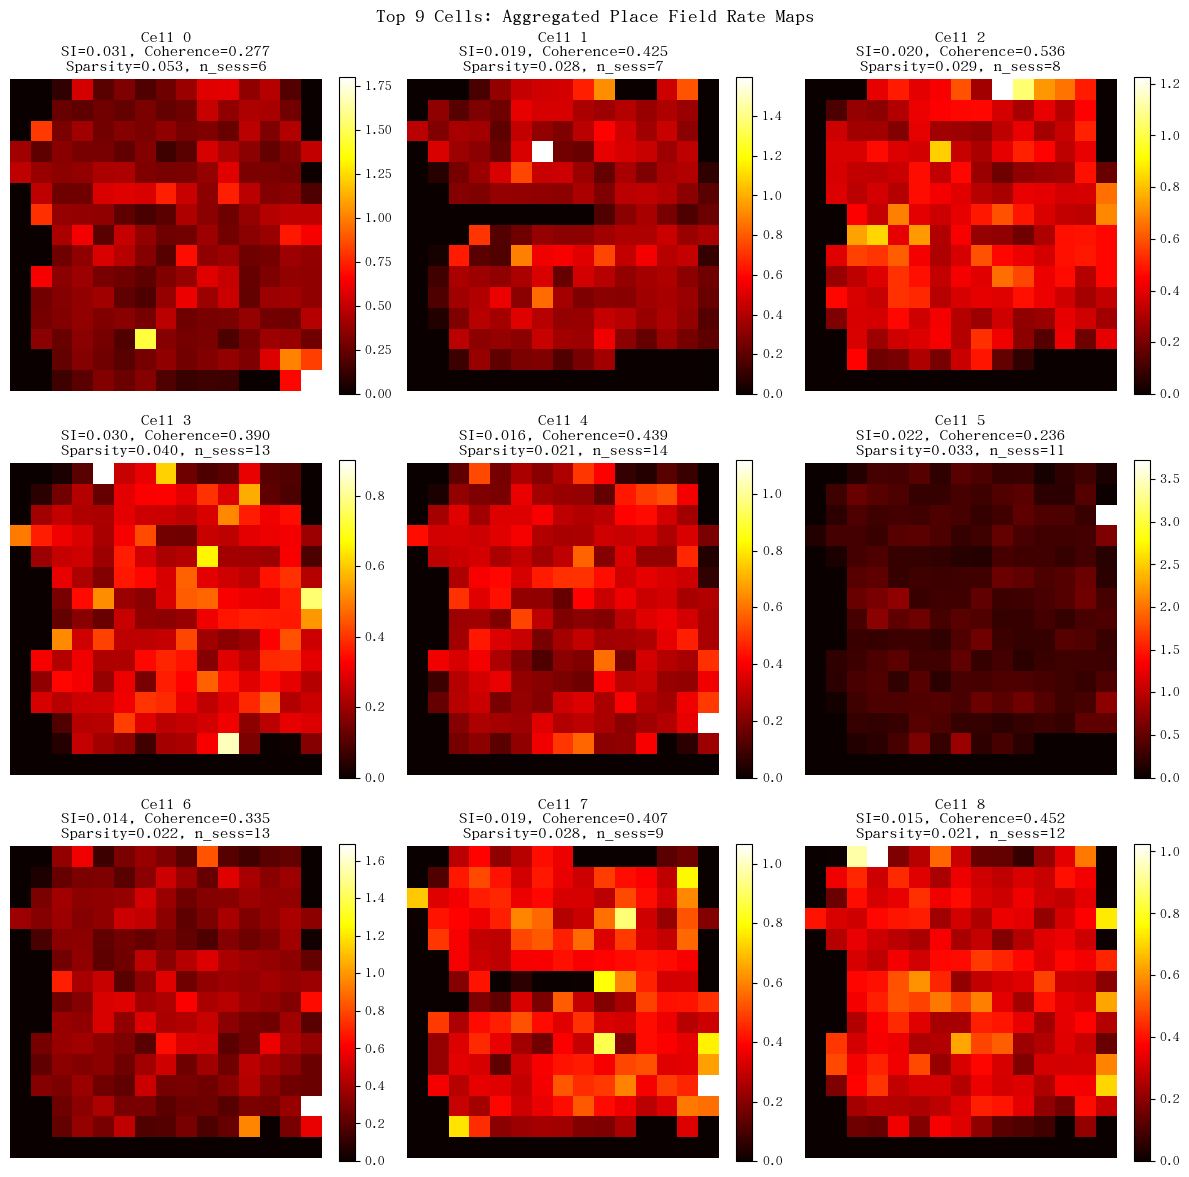

In [20]:
# ========== 绘制前9个细胞的 place field ==========

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for plot_idx in range(9):
    cell_idx = plot_idx
    
    if cell_idx not in cell_place_fields:
        axes[plot_idx].axis('off')
        continue
    
    cell_data = cell_place_fields[cell_idx]
    place_fields = cell_data['place_fields']
    pos_segment = cell_data['pos_segment']
    
    ax = axes[plot_idx]
    rate_map = place_fields[0]['rate_map']
    
    im = ax.imshow(rate_map, cmap='hot', origin='lower')
    ax.set_title(f"Cell {cell_idx}\n"
                 f"SI={place_fields[0]['spatial_info']:.3f}, "
                 f"Coherence={place_fields[0]['coherence']:.3f}\n"
                 f"Sparsity={place_fields[0]['sparsity']:.3f}, "
                 f"n_sess={cell_data['n_sessions']}")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Top 9 Cells: Aggregated Place Field Rate Maps', fontsize=14)
plt.tight_layout()
plt.show()